# ESOL Publication-Ready Analysis (ACS/IEEE Style)

Dieses Notebook ist das ESOL-Pendant zu bace_pubready_analysis_v1.

Storyline:
1. Loss stabilisation durch PT-S1 fur SEG und TAME-Fusion
2. JL als Epiphenomen: Distanztreue ist messbar, aber nicht allein performance-bestimmend
3. Gating dynamics und Similarity-Korrelationen
4. Prediction parity (y_pred vs y_real)
5. CKA storyboard + SVD evidence fur niedrige intrinsische Dimensionalitat

In [1]:
import sys
from pathlib import Path
import warnings
from itertools import combinations

import numpy as np
import pandas as pd
import torch
import deepchem as dc
import matplotlib.pyplot as plt
from matplotlib import rcParams

from scipy.spatial.distance import pdist
from scipy.stats import spearmanr

from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem, Descriptors

here = Path.cwd().resolve()
workspace_root = next((p for p in [here, *here.parents] if (p / 'models').exists()), here)
if str(workspace_root) not in sys.path:
    sys.path.insert(0, str(workspace_root))

from models.seg_predictor import SEGPredictor, SEGPredictorConfig
from models.tame_fusion_predictor import TAMEFusionPredictor, TAMEFusionPredictorConfig
from models.tame_predictor import TAMEPredictor, TAMEPredictorConfig
from utils.embedding_cache import EfficientEmbeddingCache
from utils.molecular_graph import smiles_to_graph
from utils.batched_mol_graph import batch_graphs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Workspace: {workspace_root}')
print(f'Device: {device}')

warnings.filterwarnings('ignore', message='.*findfont.*')
rcParams.update({
    'figure.dpi': 170,
    'savefig.dpi': 500,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#1f2937',
    'axes.linewidth': 0.9,
    'font.family': 'DejaVu Serif',
    'axes.labelsize': 9,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'grid.alpha': 0.22,
    'grid.color': '#9ca3af',
    'grid.linestyle': '--',
})

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (c:\Users\robsc\Home\Dev\molfusion2\.venv\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-geometric depe

Workspace: C:\Users\robsc\Home\Dev\molfusion2
Device: cuda


In [2]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32).reshape(-1)
    y_pred = np.asarray(y_pred, dtype=np.float32).reshape(-1)
    mask = np.isfinite(y_true) & np.isfinite(y_pred)
    yt = y_true[mask]
    yp = y_pred[mask]
    err = yp - yt
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))
    if yt.size > 1 and np.std(yt) > 0 and np.std(yp) > 0:
        pearson = float(np.corrcoef(yt, yp)[0, 1])
    else:
        pearson = np.nan
    return {'mae': mae, 'rmse': rmse, 'pearson': pearson, 'n_eval': int(mask.sum())}

def standardize_targets(y_train, y_val, y_test):
    y_train = np.asarray(y_train, dtype=np.float32).reshape(-1)
    y_val = np.asarray(y_val, dtype=np.float32).reshape(-1)
    y_test = np.asarray(y_test, dtype=np.float32).reshape(-1)
    mu = float(np.mean(y_train))
    sigma = float(np.std(y_train))
    if not np.isfinite(sigma) or sigma < 1e-8:
        sigma = 1.0
    def _z(x):
        return (np.asarray(x, dtype=np.float32).reshape(-1) - mu) / sigma
    def _inv(x):
        return np.asarray(x, dtype=np.float32).reshape(-1) * sigma + mu
    return _z(y_train), _z(y_val), _z(y_test), _inv, {'mean': mu, 'std': sigma}

def rdkit_descriptor_matrix(smiles_list):
    desc_names = [name for name, _ in Descriptors.descList]
    rows = []
    for smi in smiles_list:
        m = Chem.MolFromSmiles(smi)
        if m is None:
            rows.append(np.zeros((len(desc_names),), dtype=np.float32))
            continue
        vals = Descriptors.CalcMolDescriptors(m)
        cur = []
        for n in desc_names:
            v = vals.get(n, 0.0)
            try:
                fv = float(v)
            except Exception:
                fv = 0.0
            if not np.isfinite(fv):
                fv = 0.0
            cur.append(fv)
        rows.append(cur)
    return np.asarray(rows, dtype=np.float32), desc_names

def compute_tanimoto_pairs(smiles_list, radius=2, nbits=2048):
    mols = [Chem.MolFromSmiles(s) for s in smiles_list]
    fps = [AllChem.GetMorganFingerprintAsBitVect(m, radius, nBits=nbits) for m in mols if m is not None]
    vals = []
    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            vals.append(DataStructs.TanimotoSimilarity(fps[i], fps[j]))
    return np.asarray(vals, dtype=np.float32)

tasks, datasets, _ = dc.molnet.load_delaney(featurizer='ECFP', splitter='scaffold')
train_dc, valid_dc, test_dc = datasets

TRAIN_SMILES = list(train_dc.ids)
VALID_SMILES = list(valid_dc.ids)
TEST_SMILES = list(test_dc.ids)

TRAIN_Y_RAW = train_dc.y.reshape(-1).astype(np.float32)
VALID_Y_RAW = valid_dc.y.reshape(-1).astype(np.float32)
TEST_Y_RAW = test_dc.y.reshape(-1).astype(np.float32)

TRAIN_Y, VALID_Y, TEST_Y, INV_TARGET, TARGET_STATS = standardize_targets(TRAIN_Y_RAW, VALID_Y_RAW, TEST_Y_RAW)

emb_dir = workspace_root / 'cache' / 'cot_embeddings'
npz_path = emb_dir / 'solubility_fast_text_embeddings_compact.npz'
cache = EfficientEmbeddingCache.load(npz_path)
all_smiles = TRAIN_SMILES + VALID_SMILES + TEST_SMILES
all_emb = torch.from_numpy(cache.get_batch(all_smiles)).float()
n_train = len(TRAIN_SMILES)
n_valid = len(VALID_SMILES)
TRAIN_TEXT = all_emb[:n_train]
VALID_TEXT = all_emb[n_train:n_train + n_valid]
TEST_TEXT = all_emb[n_train + n_valid:]

TRAIN_DESC, DESC_NAMES = rdkit_descriptor_matrix(TRAIN_SMILES)
VALID_DESC, _ = rdkit_descriptor_matrix(VALID_SMILES)
TEST_DESC, _ = rdkit_descriptor_matrix(TEST_SMILES)

TANIMOTO_TEST = compute_tanimoto_pairs(TEST_SMILES)
DELTA_Y_TEST = pdist(TEST_Y_RAW.reshape(-1, 1), metric='euclidean')

print(f'Train/Val/Test: {len(TRAIN_SMILES)}/{len(VALID_SMILES)}/{len(TEST_SMILES)}')
print(f'Text dim: {TRAIN_TEXT.shape[1]} | Desc dim: {TRAIN_DESC.shape[1]}')
print(f'Target mean/std (train): {TARGET_STATS}')

Loading embeddings from solubility_fast_text_embeddings_compact.npz...
  Loaded 1128 entries, dim=3072
  Memory mode: mapped
Train/Val/Test: 902/113/113
Text dim: 3072 | Desc dim: 217
Target mean/std (train): {'mean': 0.0, 'std': 1.0}


[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerator
[01:06:11] DEPRECATION WARNING: please use MorganGenerat

In [3]:
SEEDS = [11, 22, 33, 44, 55]
MAX_EPOCHS = 120
BATCH_SIZE = 64

SEG_FIT = {
    'hidden_channels': 128, 'K': 3, 'num_layers': 3, 'pool': 'sum',
    'set2set_processing_steps': 6, 'fusion': 'cross_mha', 'fusion_dim': 64, 'fusion_n_heads': 8,
    'dropout': 0.3, 'fusion_dropout': 0.3, 'head_dropout': 0.3, 'head_hidden_dim': 64,
    'text_projection_dim': 64, 'learning_rate': 5e-4, 'weight_decay': 1e-2,
    'batch_size': BATCH_SIZE, 'num_epochs': MAX_EPOCHS, 'patience': 20
}

TAME_FUSION_FIT = {
    'hidden_channels': 128, 'K': 3, 'num_layers': 3, 'pool': 'sum',
    'set2set_processing_steps': 6, 'fusion': 'cross_mha', 'fusion_dim': 64, 'fusion_n_heads': 8,
    'moe_hidden_dim': 64, 'projection_dropout': 0.30, 'router_dropout': 0.35,
    'head_hidden_dim': 64, 'head_dropout': 0.3, 'learning_rate': 5e-4, 'weight_decay': 7e-2,
    'batch_size': BATCH_SIZE, 'num_epochs': MAX_EPOCHS, 'patience': 20,
    'desc_modality_dropout': 0.25, 'gate_balance_weight': 0.005
}

TAME_FIT = {
    'hidden_channels': 128, 'K': 3, 'num_layers': 3, 'pool': 'sum',
    'set2set_processing_steps': 6, 'fusion_hidden_dim': 64,
    'projection_dropout': 0.30, 'router_dropout': 0.35,
    'head_hidden_dim': 64, 'head_dropout': 0.3,
    'learning_rate': 5e-4, 'weight_decay': 7e-2,
    'batch_size': BATCH_SIZE, 'num_epochs': MAX_EPOCHS, 'patience': 20,
    'desc_modality_dropout': 0.25, 'gate_balance_weight': 0.005
}

def resolve_pretrain_checkpoint(pretrain_stage, *, hidden_channels, num_layers, K, pool):
    ckpt_dir = workspace_root / 'cache' / 'chemeleon_pretraining'
    pattern = f'cheb_foundation_stage1__h{int(hidden_channels)}__L{int(num_layers)}__K{int(K)}__pool-{pool}__*.pt'
    cands = sorted([p for p in ckpt_dir.glob(pattern) if '__fallback__' not in p.name], key=lambda p: p.stat().st_mtime, reverse=True)
    if not cands:
        raise FileNotFoundError(f'No checkpoint matching {pattern}')
    return cands[0]

def _arch_from_encoder_state(enc_state):
    layer_ids = sorted({int(k.split('.')[1]) for k in enc_state if k.startswith('layers.') and k.endswith('.weight')})
    fw = enc_state[f'layers.{layer_ids[0]}.weight']
    return {'K': int(fw.shape[0]), 'hidden_channels': int(fw.shape[-1]), 'num_layers': int(max(layer_ids) + 1)}

def load_pretrained_encoder_state(ckpt_path, expected_arch):
    payload = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    msd = payload.get('model_state_dict', {})
    enc = {k.replace('encoder.', '', 1): v for k, v in msd.items() if k.startswith('encoder.')}
    arch = _arch_from_encoder_state(enc)
    for k in ('hidden_channels', 'K', 'num_layers'):
        if int(arch[k]) != int(expected_arch[k]):
            raise RuntimeError(f'Encoder arch mismatch in {ckpt_path.name}: {k}')
    return enc

SEG_ARCH = {'hidden_channels': SEG_FIT['hidden_channels'], 'num_layers': SEG_FIT['num_layers'], 'K': SEG_FIT['K'], 'pool': SEG_FIT['pool']}
TF_ARCH = {'hidden_channels': TAME_FUSION_FIT['hidden_channels'], 'num_layers': TAME_FUSION_FIT['num_layers'], 'K': TAME_FUSION_FIT['K'], 'pool': TAME_FUSION_FIT['pool']}
TAME_ARCH = {'hidden_channels': TAME_FIT['hidden_channels'], 'num_layers': TAME_FIT['num_layers'], 'K': TAME_FIT['K'], 'pool': TAME_FIT['pool']}

seg_ckpt = resolve_pretrain_checkpoint('stage1_node', **SEG_ARCH)
tf_ckpt = resolve_pretrain_checkpoint('stage1_node', **TF_ARCH)
tame_ckpt = resolve_pretrain_checkpoint('stage1_node', **TAME_ARCH)

SEG_STAGE1 = load_pretrained_encoder_state(seg_ckpt, SEG_ARCH)
TF_STAGE1 = load_pretrained_encoder_state(tf_ckpt, TF_ARCH)
TAME_STAGE1 = load_pretrained_encoder_state(tame_ckpt, TAME_ARCH)

print('Loaded PT-S1 checkpoints:')
print('  SEG:', seg_ckpt.name)
print('  TAME-Fusion:', tf_ckpt.name)
print('  TAME:', tame_ckpt.name)

Loaded PT-S1 checkpoints:
  SEG: cheb_foundation_stage1__h128__L3__K3__pool-sum__drop-0p2000__head-256__dim-1592__subset-600000.pt
  TAME-Fusion: cheb_foundation_stage1__h128__L3__K3__pool-sum__drop-0p2000__head-256__dim-1592__subset-600000.pt
  TAME: cheb_foundation_stage1__h128__L3__K3__pool-sum__drop-0p2000__head-256__dim-1592__subset-600000.pt


In [4]:
def make_seg_config():
    return SEGPredictorConfig(
        task='regression', num_tasks=1,
        hidden_channels=SEG_FIT['hidden_channels'], K=SEG_FIT['K'], num_layers=SEG_FIT['num_layers'],
        dropout=SEG_FIT['dropout'], pool=SEG_FIT['pool'],
        set2set_processing_steps=SEG_FIT['set2set_processing_steps'],
        text_embedding_dim=int(TRAIN_TEXT.shape[1]), text_projection_dim=SEG_FIT['text_projection_dim'],
        fusion=SEG_FIT['fusion'], fusion_dim=SEG_FIT['fusion_dim'], fusion_n_heads=SEG_FIT['fusion_n_heads'], fusion_dropout=SEG_FIT['fusion_dropout'],
        head_type='mlp', head_hidden_dim=SEG_FIT['head_hidden_dim'], head_dropout=SEG_FIT['head_dropout'],
    )

def make_tame_fusion_config():
    return TAMEFusionPredictorConfig(
        task='regression', num_tasks=1,
        hidden_channels=TAME_FUSION_FIT['hidden_channels'], K=TAME_FUSION_FIT['K'], num_layers=TAME_FUSION_FIT['num_layers'],
        pool=TAME_FUSION_FIT['pool'], set2set_processing_steps=TAME_FUSION_FIT['set2set_processing_steps'],
        text_embedding_dim=int(TRAIN_TEXT.shape[1]),
        fusion=TAME_FUSION_FIT['fusion'], fusion_dim=TAME_FUSION_FIT['fusion_dim'], fusion_n_heads=TAME_FUSION_FIT['fusion_n_heads'], fusion_dropout=TAME_FUSION_FIT['router_dropout'],
        moe_hidden_dim=TAME_FUSION_FIT['moe_hidden_dim'], projection_dropout=TAME_FUSION_FIT['projection_dropout'],
        router_dropout=TAME_FUSION_FIT['router_dropout'], head_hidden_dim=TAME_FUSION_FIT['head_hidden_dim'], head_dropout=TAME_FUSION_FIT['head_dropout'],
        gate_balance_weight=TAME_FUSION_FIT['gate_balance_weight'], desc_modality_dropout=TAME_FUSION_FIT['desc_modality_dropout'],
    )

def make_tame_config():
    return TAMEPredictorConfig(
        task='regression', num_tasks=1,
        hidden_channels=TAME_FIT['hidden_channels'], K=TAME_FIT['K'], num_layers=TAME_FIT['num_layers'],
        pool=TAME_FIT['pool'], set2set_processing_steps=TAME_FIT['set2set_processing_steps'],
        text_embedding_dim=int(TRAIN_TEXT.shape[1]), fusion_hidden_dim=TAME_FIT['fusion_hidden_dim'],
        projection_dropout=TAME_FIT['projection_dropout'], router_dropout=TAME_FIT['router_dropout'],
        head_hidden_dim=TAME_FIT['head_hidden_dim'], head_dropout=TAME_FIT['head_dropout'],
        gate_balance_weight=TAME_FIT['gate_balance_weight'], desc_modality_dropout=TAME_FIT['desc_modality_dropout'],
    )

def train_seg(seed, init_state=None):
    torch.manual_seed(int(seed)); np.random.seed(int(seed))
    seg = SEGPredictor(config=make_seg_config(), device=str(device))

    graphs, in_ch = seg._precompute_graphs(TRAIN_SMILES, verbose=False)
    seg._in_channels = in_ch
    seg._build_model()
    if init_state is not None:
        seg._encoder.load_state_dict(init_state, strict=True)

    y = TRAIN_Y.astype(np.float32).reshape(-1, 1)
    yv = VALID_Y.astype(np.float32).reshape(-1, 1)
    train_idx = np.arange(len(TRAIN_SMILES))
    val_idx = list(range(len(VALID_SMILES)))
    v_graphs, _ = seg._precompute_graphs(VALID_SMILES, verbose=False)

    opt = torch.optim.AdamW(seg._get_parameters(), lr=SEG_FIT['learning_rate'], weight_decay=SEG_FIT['weight_decay'])
    loss_fn = torch.nn.MSELoss()
    rng = np.random.default_rng(int(seed))
    hist = {'train_loss': [], 'val_loss': []}
    best_state, best_val, stale = None, float('inf'), 0

    for _ in range(SEG_FIT['num_epochs']):
        tr = seg._train_epoch(graphs, TRAIN_TEXT.numpy(), y, train_idx.copy(), SEG_FIT['batch_size'], opt, loss_fn, rng)
        vl = seg._evaluate(v_graphs, VALID_TEXT.numpy(), yv, val_idx, SEG_FIT['batch_size'], loss_fn)
        hist['train_loss'].append(float(tr))
        hist['val_loss'].append(float(vl))
        if vl < best_val:
            best_val = float(vl)
            best_state = seg._get_state_dict()
            stale = 0
        else:
            stale += 1
            if stale >= SEG_FIT['patience']:
                break

    if best_state is not None:
        seg._load_state_dict(best_state)
    seg._is_fitted = True

    pred_std = np.asarray(seg.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT.numpy()), dtype=np.float32).reshape(-1)
    pred_raw = INV_TARGET(pred_std)
    metrics = regression_metrics(TEST_Y_RAW, pred_raw)
    return seg, hist, metrics

def train_tame_fusion(seed, init_state=None):
    m = TAMEFusionPredictor(config=make_tame_fusion_config(), device=str(device))
    h = m.fit(
        TRAIN_SMILES, TRAIN_Y.tolist(),
        val_smiles=VALID_SMILES, val_labels=VALID_Y.tolist(),
        text_embeddings=TRAIN_TEXT.numpy(), val_text_embeddings=VALID_TEXT.numpy(),
        descriptor_features=TRAIN_DESC, val_descriptor_features=VALID_DESC,
        num_epochs=TAME_FUSION_FIT['num_epochs'], batch_size=TAME_FUSION_FIT['batch_size'],
        learning_rate=TAME_FUSION_FIT['learning_rate'], weight_decay=TAME_FUSION_FIT['weight_decay'],
        patience=TAME_FUSION_FIT['patience'], seed=int(seed), verbose=False,
        init_encoder_state=init_state,
    )
    pred_std = np.asarray(m.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT.numpy(), descriptor_features=TEST_DESC), dtype=np.float32).reshape(-1)
    pred_raw = INV_TARGET(pred_std)
    metrics = regression_metrics(TEST_Y_RAW, pred_raw)
    return m, h, metrics

def train_tame(seed, init_state=None):
    m = TAMEPredictor(config=make_tame_config(), device=str(device))
    h = m.fit(
        TRAIN_SMILES, TRAIN_Y.tolist(),
        val_smiles=VALID_SMILES, val_labels=VALID_Y.tolist(),
        text_embeddings=TRAIN_TEXT.numpy(), val_text_embeddings=VALID_TEXT.numpy(),
        descriptor_features=TRAIN_DESC, val_descriptor_features=VALID_DESC,
        num_epochs=TAME_FIT['num_epochs'], batch_size=TAME_FIT['batch_size'],
        learning_rate=TAME_FIT['learning_rate'], weight_decay=TAME_FIT['weight_decay'],
        patience=TAME_FIT['patience'], seed=int(seed), verbose=False,
        init_encoder_state=init_state,
    )
    pred_std = np.asarray(m.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT.numpy(), descriptor_features=TEST_DESC), dtype=np.float32).reshape(-1)
    pred_raw = INV_TARGET(pred_std)
    metrics = regression_metrics(TEST_Y_RAW, pred_raw)
    return m, h, metrics

In [5]:
RUN_TRAINING = True  # Set True for fresh training
art_dir = workspace_root / 'benchmarking' / 'results'
art_dir.mkdir(parents=True, exist_ok=True)
art_pt = art_dir / 'esol_pubready_v1_runs.pt'
art_csv = art_dir / 'esol_pubready_v1_metrics.csv'

if RUN_TRAINING:
    RUNS = {
        'SEG_VANILLA': {},
        'SEG_PT_S1': {},
        'TAME_FUSION_VANILLA': {},
        'TAME_FUSION_PT_S1': {},
        'TAME_VANILLA': {},
        'TAME_PT_S1': {},
    }
    rows = []

    for seed in SEEDS:
        print(f'Running seed {seed}...')

        seg_v, seg_v_h, seg_v_m = train_seg(seed, init_state=None)
        RUNS['SEG_VANILLA'][seed] = {'history': seg_v_h, 'metrics': seg_v_m, 'model': seg_v}
        rows.append({'model': 'SEG_VANILLA', 'seed': seed, **seg_v_m})

        seg_p, seg_p_h, seg_p_m = train_seg(seed, init_state=SEG_STAGE1)
        RUNS['SEG_PT_S1'][seed] = {'history': seg_p_h, 'metrics': seg_p_m, 'model': seg_p}
        rows.append({'model': 'SEG_PT_S1', 'seed': seed, **seg_p_m})

        tf_v, tf_v_h, tf_v_m = train_tame_fusion(seed, init_state=None)
        RUNS['TAME_FUSION_VANILLA'][seed] = {'history': tf_v_h, 'metrics': tf_v_m, 'model': tf_v}
        rows.append({'model': 'TAME_FUSION_VANILLA', 'seed': seed, **tf_v_m})

        tf_p, tf_p_h, tf_p_m = train_tame_fusion(seed, init_state=TF_STAGE1)
        RUNS['TAME_FUSION_PT_S1'][seed] = {'history': tf_p_h, 'metrics': tf_p_m, 'model': tf_p}
        rows.append({'model': 'TAME_FUSION_PT_S1', 'seed': seed, **tf_p_m})

        mm_v, mm_v_h, mm_v_m = train_tame(seed, init_state=None)
        RUNS['TAME_VANILLA'][seed] = {'history': mm_v_h, 'metrics': mm_v_m, 'model': mm_v}
        rows.append({'model': 'TAME_VANILLA', 'seed': seed, **mm_v_m})

        mm_p, mm_p_h, mm_p_m = train_tame(seed, init_state=TAME_STAGE1)
        RUNS['TAME_PT_S1'][seed] = {'history': mm_p_h, 'metrics': mm_p_m, 'model': mm_p}
        rows.append({'model': 'TAME_PT_S1', 'seed': seed, **mm_p_m})

    metrics_df = pd.DataFrame(rows)
    metrics_df.to_csv(art_csv, index=False)
    torch.save(RUNS, art_pt)
else:
    RUNS = torch.load(art_pt, map_location='cpu', weights_only=False)
    metrics_df = pd.read_csv(art_csv)
    metrics_df['model'] = metrics_df['model'].replace({'TAME_VANILLA': 'TAME_VANILLA', 'TAME_PT_S1': 'TAME_PT_S1'})

    for mk in RUNS:
        for seed in RUNS[mk]:
            mdl = RUNS[mk][seed].get('model', None)
            if mdl is None:
                continue
            if hasattr(mdl, 'device'):
                mdl.device = device
            for part in ['_encoder', '_pooling', '_fusion', '_head', '_text_proj', '_moe_module']:
                comp = getattr(mdl, part, None)
                if comp is not None and hasattr(comp, 'to'):
                    comp.to(device)

display(metrics_df.groupby('model')[['rmse','mae','pearson']].agg(['mean','std']).round(4))

Running seed 11...
Running seed 22...
Running seed 33...
Running seed 44...
Running seed 55...


rmse             mae         pearson        
                       mean     std    mean     std    mean     std
model                                                              
SEG_PT_S1            0.5331  0.0175  0.4210  0.0149  0.8685  0.0154
SEG_VANILLA          0.4415  0.0075  0.3553  0.0051  0.9047  0.0023
TAME_FUSION_PT_S1    0.4275  0.0196  0.3334  0.0085  0.9172  0.0050
TAME_FUSION_VANILLA  0.4008  0.0151  0.3211  0.0115  0.9256  0.0042
TAME_PT_S1           0.4576  0.0100  0.3587  0.0107  0.8995  0.0042
TAME_VANILLA         0.4107  0.0154  0.3240  0.0114  0.9245  0.0023

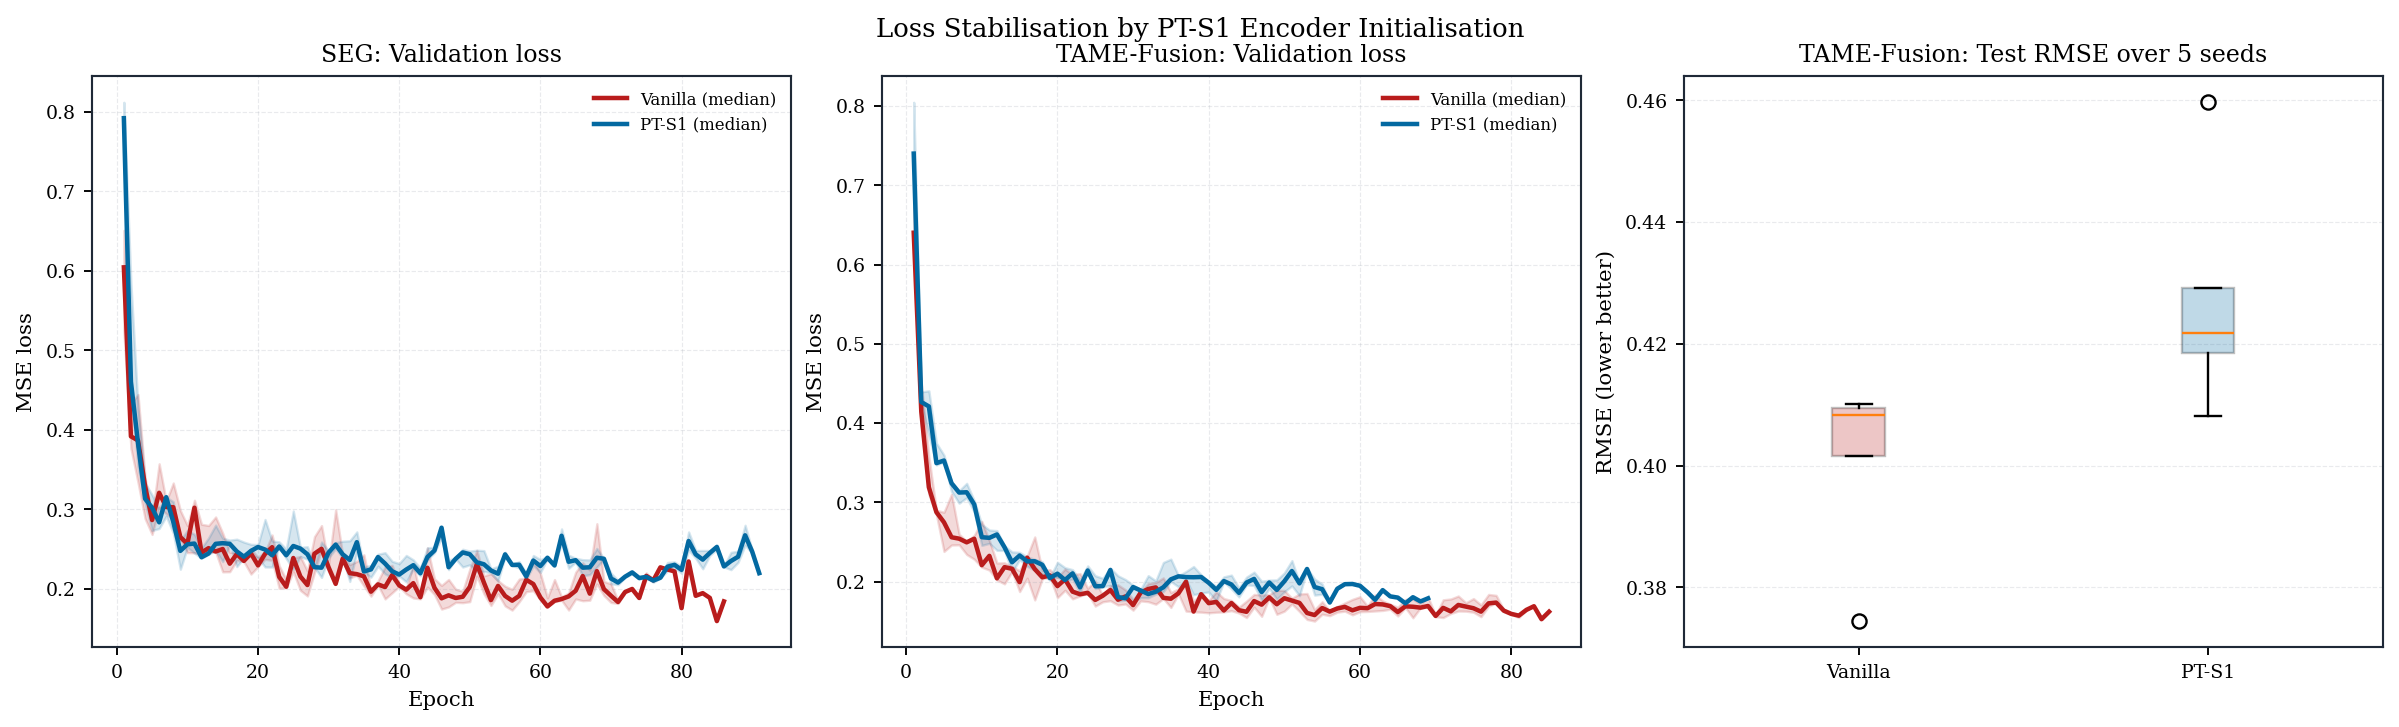

rmse             mae         pearson        
                       mean     std    mean     std    mean     std
model                                                              
SEG_PT_S1            0.5331  0.0175  0.4210  0.0149  0.8685  0.0154
SEG_VANILLA          0.4415  0.0075  0.3553  0.0051  0.9047  0.0023
TAME_FUSION_PT_S1    0.4275  0.0196  0.3334  0.0085  0.9172  0.0050
TAME_FUSION_VANILLA  0.4008  0.0151  0.3211  0.0115  0.9256  0.0042
TAME_PT_S1           0.4576  0.0100  0.3587  0.0107  0.8995  0.0042
TAME_VANILLA         0.4107  0.0154  0.3240  0.0114  0.9245  0.0023

In [6]:
# Figure 1: Loss stabilisation + RMSE panel
def aggregate_curve(model_key, metric_key):
    curves = [np.asarray(RUNS[model_key][s]['history'].get(metric_key, []), dtype=np.float32) for s in sorted(RUNS[model_key].keys())]
    curves = [c for c in curves if len(c) > 0]
    if not curves:
        return np.asarray([]), np.asarray([]), np.asarray([])
    max_len = max(len(c) for c in curves)
    arr = np.full((len(curves), max_len), np.nan, dtype=np.float32)
    for i, c in enumerate(curves):
        arr[i, :len(c)] = c
    med = np.nanmedian(arr, axis=0)
    q25 = np.nanpercentile(arr, 25, axis=0)
    q75 = np.nanpercentile(arr, 75, axis=0)
    return med, q25, q75

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.0), constrained_layout=True)
pairs = [('SEG_VANILLA', 'SEG_PT_S1', 'SEG'), ('TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1', 'TAME-Fusion')]

for c, (van, pt, name) in enumerate(pairs):
    m1, q1_1, q3_1 = aggregate_curve(van, 'val_loss')
    m2, q1_2, q3_2 = aggregate_curve(pt, 'val_loss')
    x1 = np.arange(1, len(m1) + 1)
    x2 = np.arange(1, len(m2) + 1)
    ax = axes[c]
    ax.plot(x1, m1, color='#b91c1c', lw=1.9, label='Vanilla (median)')
    ax.fill_between(x1, q1_1, q3_1, color='#b91c1c', alpha=0.16)
    ax.plot(x2, m2, color='#0369a1', lw=1.9, label='PT-S1 (median)')
    ax.fill_between(x2, q1_2, q3_2, color='#0369a1', alpha=0.16)
    ax.set_title(f'{name}: Validation loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE loss')
    ax.grid(True, ls='--', lw=0.5)
    ax.legend(frameon=False, fontsize=7)

ax = axes[2]
keys = ['TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1']
vals = [[RUNS[k][s]['metrics']['rmse'] for s in sorted(RUNS[k].keys())] for k in keys]
b = ax.boxplot(vals, patch_artist=True, tick_labels=['Vanilla', 'PT-S1'])
for patch, color in zip(b['boxes'], ['#b91c1c', '#0369a1']):
    patch.set_facecolor(color)
    patch.set_alpha(0.25)
ax.set_title('TAME-Fusion: Test RMSE over 5 seeds')
ax.set_ylabel('RMSE (lower better)')
ax.grid(True, axis='y', ls='--', lw=0.5)

fig.suptitle('Loss Stabilisation by PT-S1 Encoder Initialisation', fontsize=11, y=1.03)
plt.show()
display(metrics_df.groupby('model')[['rmse','mae','pearson']].agg(['mean','std']).round(4))

In [7]:
# Figure 2: JL epiphenomenon (vs RMSE)
def jl_stats(high_X, low_X):
    d_hi = pdist(np.asarray(high_X, dtype=np.float32), metric='euclidean')
    d_lo = pdist(np.asarray(low_X, dtype=np.float32), metric='euclidean')
    rho, _ = spearmanr(d_hi, d_lo)
    ratio = d_lo / (d_hi + 1e-10)
    med = np.median(ratio)
    p95 = np.percentile(np.abs((ratio / med) - 1.0), 95)
    return float(rho), float(p95)

def extract_tame_modalities(model, smiles, text_emb, desc):
    model._set_eval_mode()
    g_hi, t_hi, d_hi, g_lo, t_lo, d_lo = [], [], [], [], [], []
    with torch.no_grad():
        for s in range(0, len(smiles), 64):
            ss = smiles[s:s + 64]
            tt = text_emb[s:s + 64]
            dd = desc[s:s + 64]
            gs = [smiles_to_graph(x, add_hydrogens=model.config.add_hydrogens) for x in ss]
            bg = batch_graphs(gs)
            x, ei, ew, b = model._to_tensors(bg)
            tt_t = torch.from_numpy(np.asarray(tt, dtype=np.float32)).to(model.device)
            dd_t = torch.from_numpy(model._transform_descriptors(np.asarray(dd, dtype=np.float32))).to(model.device)
            node = model._encoder(x, ei, ew, b)
            graph = model._pooling(node, b)
            g_proj = model._moe_module.graph_proj(graph)
            t_proj = model._moe_module.text_proj(tt_t)
            d_proj = model._moe_module.desc_proj(dd_t)
            g_hi.append(graph.cpu().numpy()); t_hi.append(tt_t.cpu().numpy()); d_hi.append(dd_t.cpu().numpy())
            g_lo.append(g_proj.cpu().numpy()); t_lo.append(t_proj.cpu().numpy()); d_lo.append(d_proj.cpu().numpy())
    cat = lambda xs: np.concatenate(xs, axis=0)
    return {'graph_hi': cat(g_hi), 'text_hi': cat(t_hi), 'desc_hi': cat(d_hi), 'graph_lo': cat(g_lo), 'text_lo': cat(t_lo), 'desc_lo': cat(d_lo)}

jl_rows = []
for mk in ['TAME_VANILLA', 'TAME_PT_S1']:
    for seed in sorted(RUNS[mk].keys()):
        mdl = RUNS[mk][seed]['model']
        em = extract_tame_modalities(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC)
        for mod in ['graph', 'text', 'desc']:
            rho, p95 = jl_stats(em[f'{mod}_hi'], em[f'{mod}_lo'])
            jl_rows.append({'model': mk, 'seed': seed, 'modality': mod, 'rho': rho, 'p95_distortion': p95, 'rmse': RUNS[mk][seed]['metrics']['rmse']})
jl_df = pd.DataFrame(jl_rows)

epi = jl_df.groupby(['model','seed'])[['rho','p95_distortion','rmse']].mean().reset_index()
print('Spearman corr(JL rho, RMSE):', spearmanr(epi['rho'], epi['rmse']))
print('Spearman corr(JL distortion, RMSE):', spearmanr(epi['p95_distortion'], epi['rmse']))
display(jl_df.groupby(['model','modality'])[['rho','p95_distortion']].mean().round(4))

Spearman corr(JL rho, RMSE): SignificanceResult(statistic=np.float64(-0.7212121212121211), pvalue=np.float64(0.018573155089460225))
Spearman corr(JL distortion, RMSE): SignificanceResult(statistic=np.float64(0.8666666666666665), pvalue=np.float64(0.0011735381801554685))


rho  p95_distortion
model        modality                        
TAME_PT_S1   desc      0.2392          0.7487
             graph     0.3281          1.3836
             text      0.4741          1.1035
TAME_VANILLA desc      0.2855          0.6574
             graph     0.8755          0.7191
             text      0.5203          1.0398

In [ ]:
# === Figure 3: Gating dynamics (TAME) + Similarity correlations ===
plt.style.use('default')
def mean_padded_curves(curves):
    max_len = max(len(c) for c in curves)
    arr = np.full((len(curves), max_len), np.nan, dtype=np.float32)
    for i, c in enumerate(curves):
        c = np.asarray(c, dtype=np.float32)
        arr[i, :len(c)] = c
    return np.nanmean(arr, axis=0), np.nanstd(arr, axis=0)

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.2), constrained_layout=True)
fig.patch.set_facecolor('white')
for _ax in axes:
    _ax.set_facecolor('white')

# Left panel: gates
for mk, color, label_prefix in [('TAME_VANILLA', '#b91c1c', 'TAME_VANILLA'), ('TAME_PT_S1', '#0369a1', 'TAME_PT_S1')]:
    g_curves = [RUNS[mk][s]['history']['graph_gate'] for s in sorted(RUNS[mk].keys())]
    t_curves = [RUNS[mk][s]['history']['text_gate'] for s in sorted(RUNS[mk].keys())]
    d_curves = [RUNS[mk][s]['history']['desc_gate'] for s in sorted(RUNS[mk].keys())]
    gm, _ = mean_padded_curves(g_curves)
    tm, _ = mean_padded_curves(t_curves)
    dm, _ = mean_padded_curves(d_curves)
    x = np.arange(1, len(gm)+1)
    ax = axes[0]
    ax.plot(x, gm, lw=1.8, color=color, ls='-', label=f'{label_prefix} Graph')
    ax.plot(x, tm, lw=1.8, color=color, ls='--', label=f'{label_prefix} Text')
    ax.plot(x, dm, lw=1.8, color=color, ls=':', label=f'{label_prefix} Desc')

axes[0].set_title('TAME Gating Evolution (mean over 5 seeds)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Mean gate activation')
axes[0].set_ylim(0.0, 1.0)
axes[0].grid(True, ls='--', lw=0.5)
axes[0].legend(frameon=False, ncol=2, fontsize=7)

def fused_embedding_tame(model, smiles, text_emb, desc):
    model._set_eval_mode()
    outs = []
    with torch.no_grad():
        for s in range(0, len(smiles), 64):
            ss = smiles[s:s+64]
            tt = text_emb[s:s+64]
            dd = desc[s:s+64]
            gs = [smiles_to_graph(x, add_hydrogens=model.config.add_hydrogens) for x in ss]
            bg = batch_graphs(gs)
            x, ei, ew, b = model._to_tensors(bg)
            tt_t = torch.from_numpy(np.asarray(tt, dtype=np.float32)).to(model.device)
            dd_t = torch.from_numpy(model._transform_descriptors(np.asarray(dd, dtype=np.float32))).to(model.device)
            _, aux = model._forward(x, ei, ew, b, tt_t, dd_t)
            outs.append(aux['fused_emb'].cpu().numpy())
    return np.concatenate(outs, axis=0)

def fused_embedding_tame_fusion(model, smiles, text_emb, desc):
    model._set_eval_mode()
    outs = []
    with torch.no_grad():
        for s in range(0, len(smiles), 64):
            ss = smiles[s:s+64]
            tt = text_emb[s:s+64]
            dd = desc[s:s+64]
            gs = [smiles_to_graph(x, add_hydrogens=model.config.add_hydrogens) for x in ss]
            bg = batch_graphs(gs)
            x, ei, ew, b = model._to_tensors(bg)
            tt_t = torch.from_numpy(np.asarray(tt, dtype=np.float32)).to(model.device)
            dd_t = torch.from_numpy(model._transform_descriptors(np.asarray(dd, dtype=np.float32))).to(model.device)
            _, aux = model._forward(x, ei, ew, b, tt_t, dd_t)
            outs.append(aux['fused_emb'].cpu().numpy())
    return np.concatenate(outs, axis=0)

corr_rows = []
for mk in ['TAME_VANILLA', 'TAME_PT_S1', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1']:
    for seed in sorted(RUNS[mk].keys()):
        mdl = RUNS[mk][seed]['model']
        if mk.startswith('TAME'):
            emb = fused_embedding_tame(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC)
        else:
            emb = fused_embedding_tame_fusion(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC)

        assert emb.shape[0] == len(TEST_SMILES), f'Unexpected extracted size for {mk} seed={seed}'
        assert np.isfinite(emb).all(), f'Non-finite fused embeddings for {mk} seed={seed}'

        cos_sim = 1.0 - pdist(emb, metric='cosine')
        l2_dist = pdist(emb, metric='euclidean')

        rho_t, _ = spearmanr(TANIMOTO_TEST, cos_sim, nan_policy='omit')
        rho_y, _ = spearmanr(DELTA_Y_TEST, l2_dist, nan_policy='omit')

        display_model = 'TAME_VANILLA' if mk == 'TAME_VANILLA' else ('TAME_PT_S1' if mk == 'TAME_PT_S1' else mk)
        corr_rows.append({
            'model': display_model,
            'seed': seed,
            'rho_tanimoto_cos': float(rho_t) if np.isfinite(rho_t) else np.nan,
            'rho_deltaY_l2': float(rho_y) if np.isfinite(rho_y) else np.nan,
        })

corr_df = pd.DataFrame(corr_rows)

order = ['TAME_VANILLA', 'TAME_PT_S1', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1']
labels = ['TAME\nVanilla', 'TAME\nPT-S1', 'TFusion\nVanilla', 'TFusion\nPT-S1']
p_mean = corr_df.groupby('model')[['rho_tanimoto_cos', 'rho_deltaY_l2']].mean().reindex(order)
p_std = corr_df.groupby('model')[['rho_tanimoto_cos', 'rho_deltaY_l2']].std().reindex(order)

x = np.arange(len(order))
w = 0.36
axes[1].bar(x - w/2, p_mean['rho_tanimoto_cos'].values, yerr=p_std['rho_tanimoto_cos'].fillna(0).values, capsize=3, width=w, color='#2563eb', alpha=0.85, label='rho(Tanimoto, CosSim)')
axes[1].bar(x + w/2, p_mean['rho_deltaY_l2'].values, yerr=p_std['rho_deltaY_l2'].fillna(0).values, capsize=3, width=w, color='#f97316', alpha=0.85, label='rho(|Delta y|, L2)')
axes[1].set_xticks(x, labels)
axes[1].set_title('Similarity Correlation (mean +- SD over 5 seeds)')
axes[1].set_ylabel('Spearman rho')
axes[1].grid(True, axis='y', ls='--', lw=0.5)
axes[1].legend(frameon=False, fontsize=8)

for ax, label in zip(axes, ['A', 'B']):
    ax.text(-0.12, 1.05, label, transform=ax.transAxes, fontsize=11, fontweight='bold')

plt.show()
display(corr_df.groupby('model')[['rho_tanimoto_cos','rho_deltaY_l2']].agg(['mean','std']).round(4))

## 4. Prediction Parity Plots (y_pred vs y_real)

Visuelle Kalibrierungsdiagnostik mit Identitätsgerade (y_pred = y_real) für alle Modellvarianten über alle Seeds.

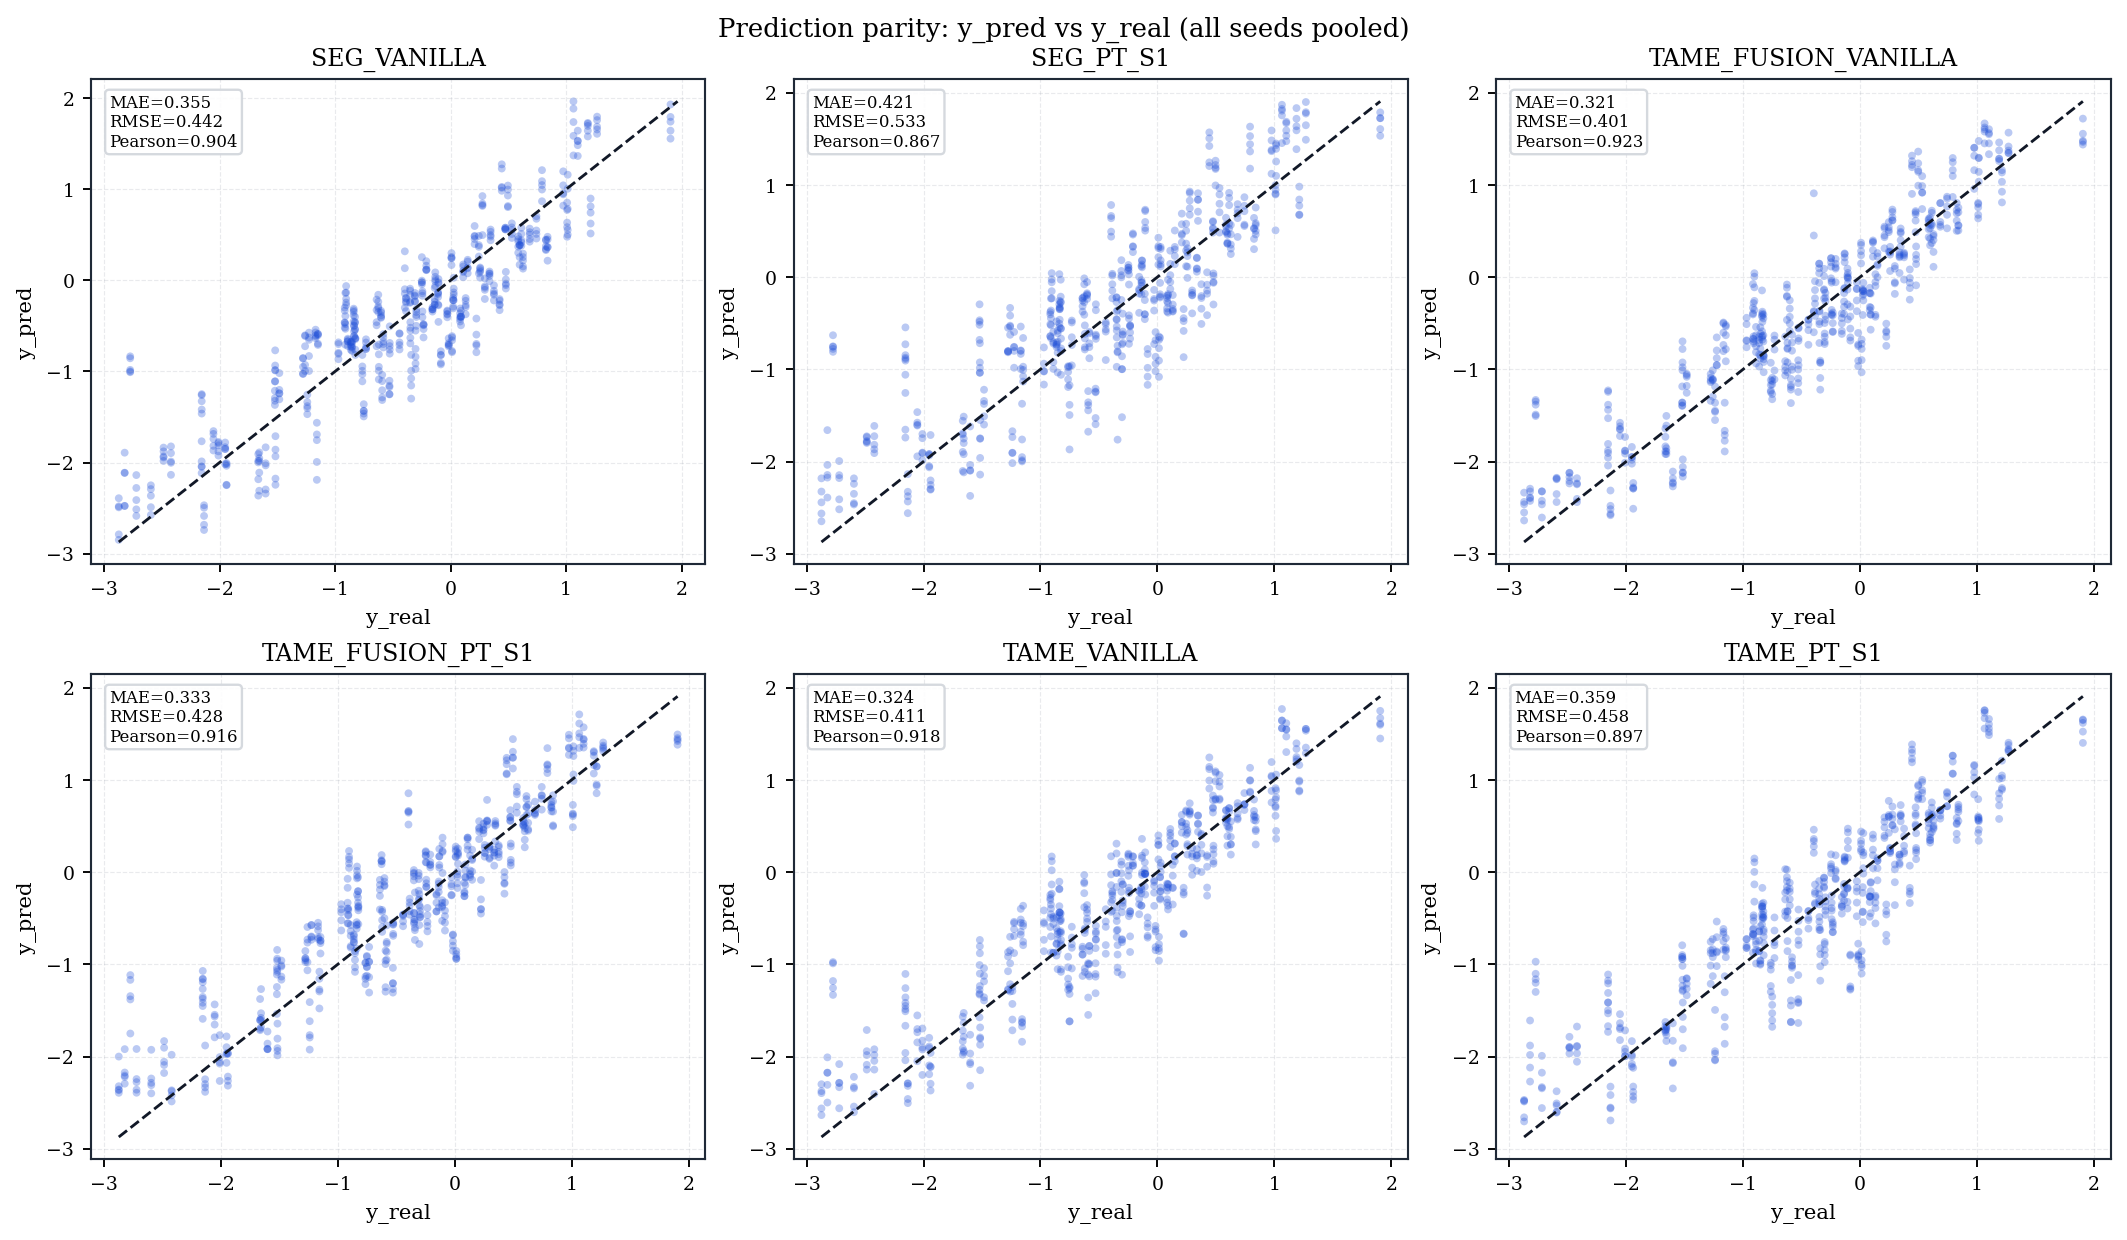

In [8]:
# Figure 3: Prediction parity for regression
def collect_test_predictions(model_key):
    rows = []
    for seed in sorted(RUNS[model_key].keys()):
        mdl = RUNS[model_key][seed]['model']
        if model_key.startswith('SEG'):
            pred_std = mdl.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT.numpy())
        else:
            pred_std = mdl.predict_batch(TEST_SMILES, text_embeddings=TEST_TEXT.numpy(), descriptor_features=TEST_DESC)
        pred = INV_TARGET(np.asarray(pred_std, dtype=np.float32).reshape(-1))
        yt = TEST_Y_RAW.reshape(-1).astype(np.float32)
        for y_t, y_p in zip(yt, pred):
            rows.append({'model_key': model_key, 'seed': int(seed), 'y_true': float(y_t), 'y_pred': float(y_p)})
    return pd.DataFrame(rows)

model_order = ['SEG_VANILLA', 'SEG_PT_S1', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1', 'TAME_VANILLA', 'TAME_PT_S1']
model_order = [m for m in model_order if m in RUNS]
parity_df = pd.concat([collect_test_predictions(k) for k in model_order], ignore_index=True)

fig, axes = plt.subplots(2, 3, figsize=(12.4, 7.0), constrained_layout=True)
for ax, key in zip(axes.flatten(), model_order):
    sub = parity_df[parity_df['model_key'] == key]
    x = sub['y_true'].values
    y = sub['y_pred'].values
    ax.scatter(x, y, s=11, alpha=0.30, color='#1d4ed8', edgecolors='none')
    lo = float(min(np.min(x), np.min(y)))
    hi = float(max(np.max(x), np.max(y)))
    ax.plot([lo, hi], [lo, hi], color='#111827', lw=1.2, ls='--')
    mae = float(np.mean(np.abs(y - x)))
    rmse = float(np.sqrt(np.mean((y - x) ** 2)))
    r = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan
    ax.set_title(key.replace('TAME', 'TAME'))
    ax.set_xlabel('y_real')
    ax.set_ylabel('y_pred')
    ax.grid(True, ls='--', lw=0.5)
    ax.text(0.03, 0.97, f'MAE={mae:.3f}\nRMSE={rmse:.3f}\nPearson={r:.3f}', transform=ax.transAxes, va='top', fontsize=7, bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='#d1d5db', alpha=0.9))

fig.suptitle('Prediction parity: y_pred vs y_real (all seeds pooled)', fontsize=11, y=1.02)
plt.show()

## 5. CKA Storyboard (Orthogonality, Stabilisation, Fusion-Dominance, JL Bottleneck)

Dieser Block operationalisiert die vier Kernmuster für einen publikationsreifen Geometrie-Report analog zum BACE-Notebook.

In [9]:
# Figure 4/5: CKA storyboard + SVD geometry (sanity-checked)
def linear_cka(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    hsic_xy = np.linalg.norm(X.T @ Y, ord='fro') ** 2
    hsic_xx = np.linalg.norm(X.T @ X, ord='fro') ** 2
    hsic_yy = np.linalg.norm(Y.T @ Y, ord='fro') ** 2
    return float(hsic_xy / (np.sqrt(hsic_xx * hsic_yy) + 1e-10))

def _cat(xs):
    return np.concatenate(xs, axis=0) if xs else np.empty((0, 1), dtype=np.float32)

def extract_seg_modalities(model, smiles, text_emb_np, labels_np, batch_size=64):
    model._set_eval_mode()
    graphs, _ = model._precompute_graphs(smiles, verbose=False)
    idx = np.arange(len(smiles))
    labels = labels_np.reshape(-1, 1).astype(np.float32)
    g_list, t_raw_list, t_proj_list, f_list = [], [], [], []

    with torch.no_grad():
        for s in range(0, len(idx), batch_size):
            bidx = idx[s:s + batch_size]
            pack = model._make_batch(graphs, text_emb_np, labels, bidx)
            if pack is None:
                continue
            x, ei, ew, b, bt, _ = pack
            x, ei, ew, b = model._numpy_to_tensors(x, ei, ew, b)
            bt_t = torch.from_numpy(bt.astype(np.float32)).to(model.device)
            node = model._encoder(x, ei, ew, b)
            g = model._pooling(node, b)
            t_proj = model._text_proj(bt_t) if model._text_proj is not None else bt_t
            f = model._fusion(g, t_proj)
            g_list.append(g.cpu().numpy())
            t_raw_list.append(bt_t.cpu().numpy())
            t_proj_list.append(t_proj.cpu().numpy())
            f_list.append(f.cpu().numpy())

    return {
        'graph': _cat(g_list),
        'text_raw': _cat(t_raw_list),
        'text_proj': _cat(t_proj_list),
        'fused': _cat(f_list),
        'text_proj_source': 'seg_text_proj' if getattr(model, '_text_proj', None) is not None else 'identity_no_text_proj',
    }

def extract_moe_modalities(model, smiles, text_emb_np, desc_np, batch_size=64):
    model._set_eval_mode()
    g_list, t_raw_list, t_proj_list, f_list = [], [], [], []

    if hasattr(model, '_moe_module') and hasattr(model._moe_module, 'text_proj'):
        proj_source = 'moe_text_proj'
    elif hasattr(model, '_text_proj') and model._text_proj is not None:
        proj_source = 'tame_text_proj'
    else:
        proj_source = 'identity_no_text_proj'

    with torch.no_grad():
        for s in range(0, len(smiles), batch_size):
            ss = smiles[s:s + batch_size]
            tt = np.asarray(text_emb_np[s:s + batch_size], dtype=np.float32)
            dd = np.asarray(desc_np[s:s + batch_size], dtype=np.float32)
            gs = [smiles_to_graph(x, add_hydrogens=model.config.add_hydrogens) for x in ss]
            bg = batch_graphs(gs)
            x, ei, ew, b = model._to_tensors(bg)
            tt_t = torch.from_numpy(tt).to(model.device)
            dd_t = torch.from_numpy(model._transform_descriptors(dd)).to(model.device)

            out = model._forward(x, ei, ew, b, tt_t, dd_t)
            _, aux = out if isinstance(out, tuple) else (out, {})
            node = model._encoder(x, ei, ew, b)
            g = model._pooling(node, b)

            if hasattr(model, '_moe_module') and hasattr(model._moe_module, 'text_proj'):
                t_proj = model._moe_module.text_proj(tt_t)
            elif hasattr(model, '_text_proj') and model._text_proj is not None:
                t_proj = model._text_proj(tt_t)
            else:
                t_proj = tt_t

            seg_emb = model._fusion(g, t_proj) if hasattr(model, '_fusion') and model._fusion is not None else None

            fused = aux.get('fused_emb', None)
            if fused is None:
                if seg_emb is not None and hasattr(model, '_moe_module') and hasattr(model._moe_module, 'seg_proj'):
                    fused = model._moe_module.seg_proj(seg_emb)
                elif seg_emb is not None:
                    fused = seg_emb if seg_emb.shape == t_proj.shape else torch.cat([seg_emb, t_proj], dim=-1)
                else:
                    fused = g if g.shape == t_proj.shape else torch.cat([g, t_proj], dim=-1)

            g_list.append(g.cpu().numpy())
            t_raw_list.append(tt_t.cpu().numpy())
            t_proj_list.append(t_proj.cpu().numpy())
            f_list.append(fused.cpu().numpy())

    return {
        'graph': _cat(g_list),
        'text_raw': _cat(t_raw_list),
        'text_proj': _cat(t_proj_list),
        'fused': _cat(f_list),
        'text_proj_source': proj_source,
    }

model_keys = ['SEG_VANILLA', 'SEG_PT_S1', 'TAME_FUSION_VANILLA', 'TAME_FUSION_PT_S1', 'TAME_VANILLA', 'TAME_PT_S1']
model_keys = [k for k in model_keys if k in RUNS]

EMB = {}
sanity_raw_proj_rows = []
for mk in model_keys:
    EMB[mk] = {}
    for seed in sorted(RUNS[mk].keys()):
        mdl = RUNS[mk][seed]['model']
        if mk.startswith('SEG'):
            pack = extract_seg_modalities(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_Y, batch_size=64)
        else:
            pack = extract_moe_modalities(mdl, TEST_SMILES, TEST_TEXT.numpy(), TEST_DESC, batch_size=64)

        for name in ['graph', 'text_raw', 'text_proj', 'fused']:
            assert pack[name].shape[0] == len(TEST_SMILES), f'Length mismatch: {mk} seed={seed} {name}'
            assert np.isfinite(pack[name]).all(), f'Non-finite values: {mk} seed={seed} {name}'

        raw = pack['text_raw']
        proj = pack['text_proj']
        same_shape = raw.shape == proj.shape
        rel_change = np.nan
        if same_shape:
            denom = np.linalg.norm(raw) + 1e-12
            rel_change = float(np.linalg.norm(raw - proj) / denom)

        sanity_raw_proj_rows.append({
            'model_key': mk,
            'seed': int(seed),
            'raw_dim': int(raw.shape[1]),
            'proj_dim': int(proj.shape[1]),
            'proj_source': pack.get('text_proj_source', 'unknown'),
            'same_shape_raw_proj': bool(same_shape),
            'rel_change_norm_raw_to_proj': rel_change,
        })

        EMB[mk][seed] = pack

sanity_raw_proj_df = pd.DataFrame(sanity_raw_proj_rows)
display(
    sanity_raw_proj_df.groupby(['model_key', 'proj_source'])[['raw_dim', 'proj_dim', 'same_shape_raw_proj', 'rel_change_norm_raw_to_proj']].agg(['mean', 'std']).round(6)
)

cka_rows = []
for mk in model_keys:
    for seed in sorted(EMB[mk].keys()):
        c_gt = linear_cka(EMB[mk][seed]['graph'], EMB[mk][seed]['text_proj'])
        source = EMB[mk][seed].get('text_proj_source', 'unknown')
        if source == 'identity_no_text_proj':
            c_rt = np.nan
        else:
            c_rt = linear_cka(EMB[mk][seed]['text_raw'], EMB[mk][seed]['text_proj'])
        cka_rows.append({
            'model_key': mk,
            'seed': int(seed),
            'proj_source': source,
            'cka_graph_textproj': c_gt,
            'cka_raw_proj': c_rt,
        })
cka_df = pd.DataFrame(cka_rows)
display(cka_df.groupby('model_key')[['cka_graph_textproj', 'cka_raw_proj']].agg(['mean', 'std']).round(4))

def svd_vals(X, center=False):
    X = np.asarray(X, dtype=np.float32)
    if center:
        X = X - X.mean(axis=0, keepdims=True)
    return np.linalg.svd(X, full_matrices=False, compute_uv=False)

def rank90(S):
    p = (S ** 2) / (np.sum(S ** 2) + 1e-12)
    c = np.cumsum(p)
    return int(np.searchsorted(c, 0.90) + 1)

def effective_rank(S):
    p = (S ** 2) / (np.sum(S ** 2) + 1e-12)
    p = p[p > 1e-12]
    return float(np.exp(-np.sum(p * np.log(p))))

def embedding_integrity_stats(X):
    X = np.asarray(X, dtype=np.float32)
    n_samples, n_dim = X.shape
    X_round = np.round(X, 6)
    n_unique = int(np.unique(X_round, axis=0).shape[0])
    std_dim = np.std(X, axis=0)
    n_active = int(np.sum(std_dim > 1e-6))
    return {
        'n_samples': int(n_samples),
        'n_dim': int(n_dim),
        'n_unique_rows_round6': n_unique,
        'unique_fraction_round6': float(n_unique / max(n_samples, 1)),
        'active_dims_std_gt_1e-6': n_active,
        'active_dim_fraction': float(n_active / max(n_dim, 1)),
        'mean_dim_std': float(np.mean(std_dim)),
        'median_dim_std': float(np.median(std_dim)),
    }

raw_text = None
geom_rows = []
for mk in model_keys:
    for seed in sorted(EMB[mk].keys()):
        pack = EMB[mk][seed]
        if raw_text is None:
            raw_text = np.asarray(pack['text_raw'], dtype=np.float32)
        Sg = svd_vals(pack['graph'], center=True)
        St = svd_vals(pack['text_proj'], center=True)
        Sf = svd_vals(pack['fused'], center=True)
        geom_rows.append({
            'model_key': mk,
            'seed': int(seed),
            'eff_rank_graph': effective_rank(Sg),
            'eff_rank_textproj': effective_rank(St),
            'eff_rank_fused': effective_rank(Sf),
            'rank90_graph': rank90(Sg),
            'rank90_textproj': rank90(St),
            'rank90_fused': rank90(Sf),
        })
geom_df = pd.DataFrame(geom_rows)

if raw_text is None:
    raise RuntimeError('No raw text embeddings available in EMB for SVD analysis.')

raw_integrity = embedding_integrity_stats(raw_text)
display(pd.DataFrame([raw_integrity]))

S_raw_unc = svd_vals(raw_text, center=False)
S_raw_ctr = svd_vals(raw_text, center=True)
raw_svd_df = pd.DataFrame([
    {
        'eff_rank_raw_uncentered': effective_rank(S_raw_unc),
        'rank90_raw_uncentered': rank90(S_raw_unc),
        'eff_rank_raw_centered': effective_rank(S_raw_ctr),
        'rank90_raw_centered': rank90(S_raw_ctr),
    }
])
display(raw_svd_df)

display(
    geom_df.groupby('model_key')[['eff_rank_graph', 'eff_rank_textproj', 'eff_rank_fused', 'rank90_graph', 'rank90_textproj', 'rank90_fused']].agg(['mean', 'std']).round(3)
)

print('Sanity note: identity_no_text_proj means JL raw-vs-proj is undefined (reported as NaN).')
print('SVD ranks are reported on centered representations to avoid mean-vector artifacts.')

results_dir = workspace_root / 'benchmarking' / 'results'
results_dir.mkdir(parents=True, exist_ok=True)
metrics_df.to_csv(results_dir / 'esol_pubready_v1_metrics.csv', index=False)
cka_df.to_csv(results_dir / 'esol_pubready_v1_cka.csv', index=False)
geom_df.to_csv(results_dir / 'esol_pubready_v1_svd.csv', index=False)
raw_svd_df.to_csv(results_dir / 'esol_pubready_v1_raw_svd_sanity.csv', index=False)
sanity_raw_proj_df.to_csv(results_dir / 'esol_pubready_v1_raw_proj_sanity.csv', index=False)
print('Saved ESOL pubready artifacts to benchmarking/results/.')

raw_dim      proj_dim       \
                                             mean  std     mean  std   
model_key           proj_source                                        
TAME_PT_S1          moe_text_proj          3072.0  0.0     64.0  0.0   
TAME_VANILLA        moe_text_proj          3072.0  0.0     64.0  0.0   
SEG_PT_S1           seg_text_proj          3072.0  0.0     64.0  0.0   
SEG_VANILLA         seg_text_proj          3072.0  0.0     64.0  0.0   
TAME_FUSION_PT_S1   identity_no_text_proj  3072.0  0.0   3072.0  0.0   
TAME_FUSION_VANILLA identity_no_text_proj  3072.0  0.0   3072.0  0.0   

                                          same_shape_raw_proj       \
                                                         mean  std   
model_key           proj_source                                      
TAME_PT_S1          moe_text_proj                         0.0  0.0   
TAME_VANILLA        moe_text_proj                         0.0  0.0   
SEG_PT_S1           seg_text_proj                         0.0  0.0   
SEG_VANILLA         seg_text_proj                         0.0  0.0   
TAME_FUSION_PT_S1   identity_no_text_proj                 1.0  0.0   
TAME_FUSION_VANILLA identity_no_text_proj                 1.0  0.0   

                                          rel_change_norm_raw_to_proj       
                                                                 mean  std  
model_key           proj_source                                             
TAME_PT_S1          moe_text_proj                                 NaN  NaN  
TAME_VANILLA        moe_text_proj                                 NaN  NaN  
SEG_PT_S1           seg_text_proj                                 NaN  NaN  
SEG_VANILLA         seg_text_proj                                 NaN  NaN  
TAME_FUSION_PT_S1   identity_no_text_proj                         0.0  0.0  
TAME_FUSION_VANILLA identity_no_text_proj                         0.0  0.0

cka_graph_textproj         cka_raw_proj        
                                  mean     std         mean     std
model_key                                                          
TAME_PT_S1                      0.2980  0.0527       0.3325  0.0169
TAME_VANILLA                    0.4665  0.0442       0.4394  0.0104
SEG_PT_S1                       0.3018  0.0301       0.5387  0.0504
SEG_VANILLA                     0.4671  0.0387       0.6608  0.0261
TAME_FUSION_PT_S1               0.3453  0.0151          NaN     NaN
TAME_FUSION_VANILLA             0.2539  0.0159          NaN     NaN

,n_samples,n_dim,n_unique_rows_round6,unique_fraction_round6,active_dims_std_gt_1e-6,active_dim_fraction,mean_dim_std,median_dim_std
0,113,3072,113,1.0,3072,1.0,0.009412,0.008885


,eff_rank_raw_uncentered,rank90_raw_uncentered,eff_rank_raw_centered,rank90_raw_centered
0,5.347609,17,41.347839,50


eff_rank_graph        eff_rank_textproj         \
                              mean    std              mean    std   
model_key                                                            
TAME_PT_S1                   6.970  0.437             2.621  0.225   
TAME_VANILLA                 1.695  0.133             3.592  0.459   
SEG_PT_S1                    7.050  0.560             6.648  1.590   
SEG_VANILLA                  1.442  0.066             8.168  1.321   
TAME_FUSION_PT_S1            6.518  0.335            41.348  0.000   
TAME_FUSION_VANILLA          1.799  0.291            41.348  0.000   

                    eff_rank_fused        rank90_graph        rank90_textproj  \
                              mean    std         mean    std            mean   
model_key                                                                       
TAME_PT_S1                   3.181  0.204          6.6  0.548             3.0   
TAME_VANILLA                 2.684  0.147          2.0  0.000             4.6   
SEG_PT_S1                    1.898  0.165          7.4  0.548             7.4   
SEG_VANILLA                  1.614  0.060          1.6  0.548             9.2   
TAME_FUSION_PT_S1            2.783  0.146          7.2  0.447            50.0   
TAME_FUSION_VANILLA          2.557  0.156          1.8  0.447            50.0   

                           rank90_fused         
                       std         mean    std  
model_key                                       
TAME_PT_S1           0.000          5.6  0.894  
TAME_VANILLA         0.548          4.4  0.894  
SEG_PT_S1            2.302          2.0  0.000  
SEG_VANILLA          1.483          1.8  0.447  
TAME_FUSION_PT_S1    0.000          4.2  0.447  
TAME_FUSION_VANILLA  0.000          3.6  0.548

Sanity note: identity_no_text_proj means JL raw-vs-proj is undefined (reported as NaN).
SVD ranks are reported on centered representations to avoid mean-vector artifacts.
Saved ESOL pubready artifacts to benchmarking/results/.


In [ ]:
# === Export report assets ===
summary_path = art_dir / 'esol_pubready_v1_summary.csv'
corr_path = art_dir / 'esol_pubready_v1_similarity_corr.csv'
jl_path = art_dir / 'esol_pubready_v1_jl.csv'

metrics_df.to_csv(summary_path, index=False)
if 'corr_df' in globals() and isinstance(corr_df, pd.DataFrame):
    corr_df.to_csv(corr_path, index=False)
if 'jl_df' in globals() and isinstance(jl_df, pd.DataFrame):
    jl_df.to_csv(jl_path, index=False)

print('Saved:')
print(' ', summary_path.resolve())
if corr_path.exists():
    print(' ', corr_path.resolve())
if jl_path.exists():
    print(' ', jl_path.resolve())
print('Notebook artifacts:', art_pt.resolve(), art_csv.resolve())